In [1]:
import sys
!{sys.executable} -m pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


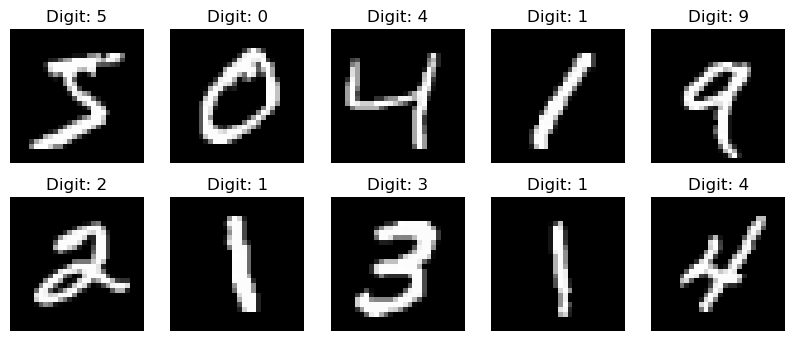

In [2]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Digit: " + str(y_train[i]))
    plt.axis('off')

plt.show()


In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9102 - loss: 0.3087 - val_accuracy: 0.9678 - val_loss: 0.1238
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9549 - loss: 0.1503 - val_accuracy: 0.9723 - val_loss: 0.0999
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9661 - loss: 0.1120 - val_accuracy: 0.9742 - val_loss: 0.0842
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9723 - loss: 0.0900 - val_accuracy: 0.9777 - val_loss: 0.0762
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9763 - loss: 0.0755 - val_accuracy: 0.9797 - val_loss: 0.0723


In [5]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0778
Test Accuracy: 0.9765999913215637


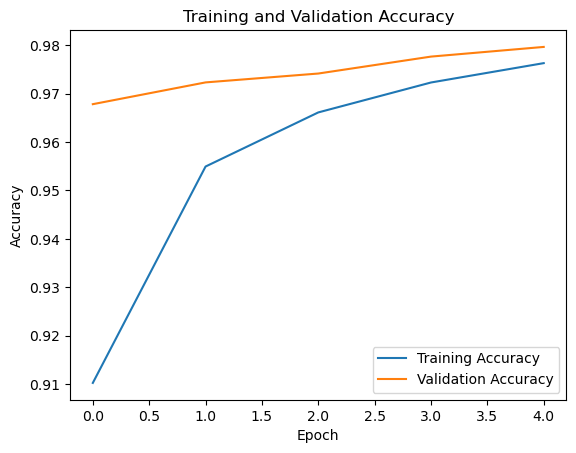

In [6]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

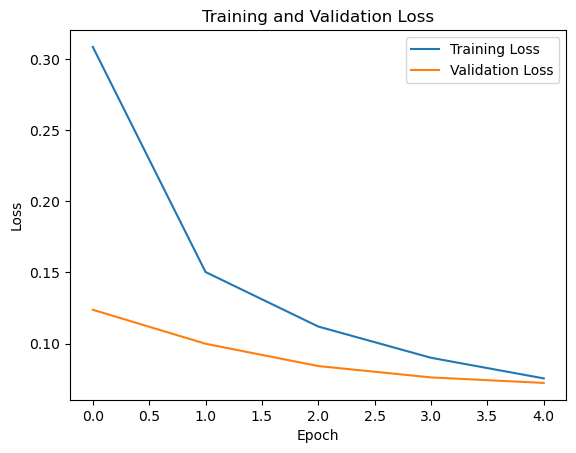

In [7]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [8]:
predictions = model.predict(X_test[:5])

predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels:   ", y_test[:5])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
Actual labels:    [7 2 1 0 4]
Predicted labels: [7 2 1 0 4]


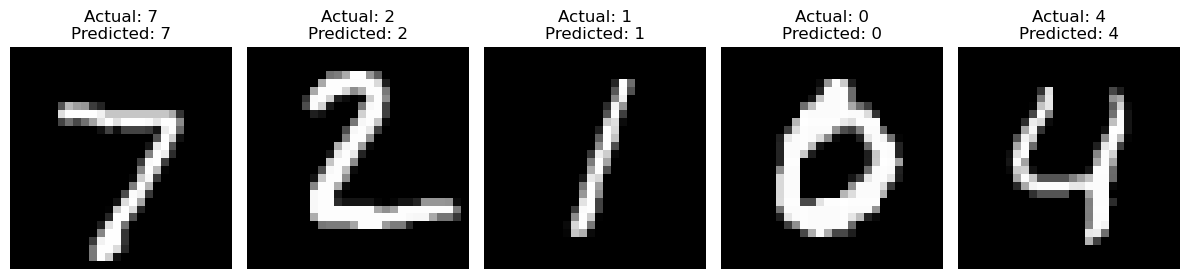

In [9]:
plt.figure(figsize=(12,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8867 - loss: 0.3855 - val_accuracy: 0.9563 - val_loss: 0.1596
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9388 - loss: 0.2050 - val_accuracy: 0.9673 - val_loss: 0.1182
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9503 - loss: 0.1640 - val_accuracy: 0.9710 - val_loss: 0.1049
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9578 - loss: 0.1396 - val_accuracy: 0.9743 - val_loss: 0.0908
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9627 - loss: 0.1233 - val_accuracy: 0.9763 - val_loss: 0.0874


In [11]:
loss2, accuracy2 = model2.evaluate(X_test, y_test)

print("Original Model Accuracy:", test_accuracy)
print("New Model Accuracy:", accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0971  
Original Model Accuracy: 0.9765999913215637
New Model Accuracy: 0.9714999794960022
